In [19]:
import numpy as np
import matplotlib.pyplot as plt


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
%cd '/content/drive/MyDrive/Colab Notebooks/'

/content/drive/MyDrive/Colab Notebooks


In [13]:
!unzip data.zip

Archive:  data.zip
  inflating: y.npy                   
  inflating: x.npy                   


In [21]:
# Load data
X = np.load('x.npy')
Y = np.load('y.npy')

In [22]:
print(x.shape, y.shape)

(800, 1000, 501) (800,)


In [24]:
print(type(X),type(Y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [25]:
print(X)

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


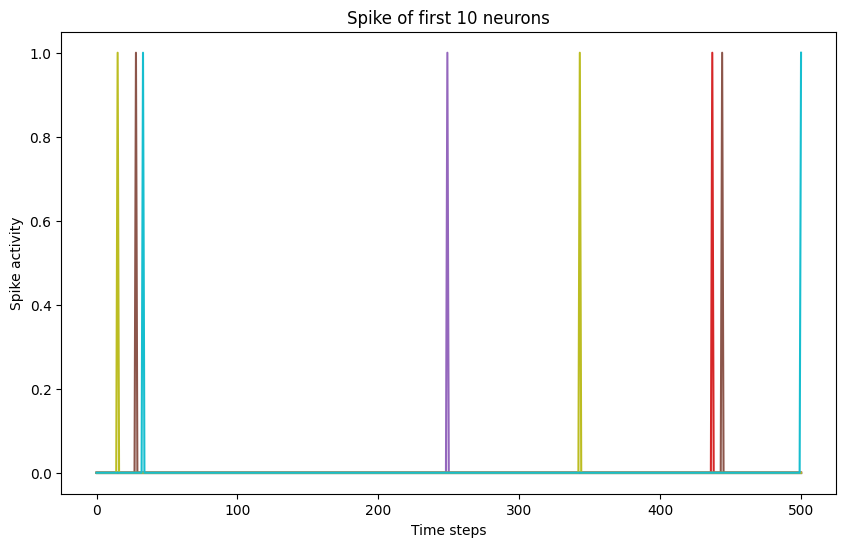

In [28]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.plot(X[i, 0, :], label=f'Sample {i+1}')
plt.title('Spike of first 10 neurons')
plt.xlabel('Time steps')
plt.ylabel('Spike activity')
plt.show()

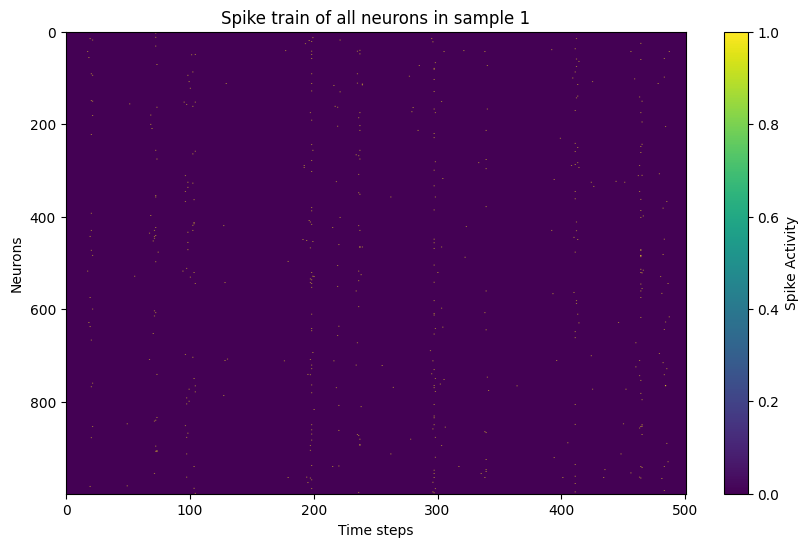

In [32]:
plt.figure(figsize=(10, 6))
plt.imshow(X[0, :, :], aspect='auto', cmap='viridis')
plt.title('Spike train of all neurons in sample 1')
plt.xlabel('Time steps')
plt.ylabel('Neurons')
plt.colorbar(label='Spike Activity')
plt.show()

# Average Firing Transformation

This involves calculating the average spike rate for each neuron across the time steps for each stimulus. This method gives us an idea of how active each neuron is over the entire time period.



In [34]:
avg_firing_rate = np.mean(X, axis=2)
print("Shape of transformed data (average firing rate):", avg_firing_rate.shape)

Shape of transformed data (average firing rate): (800, 1000)


# Exploratory Analysis

In [35]:
from scipy.stats import gaussian_kde

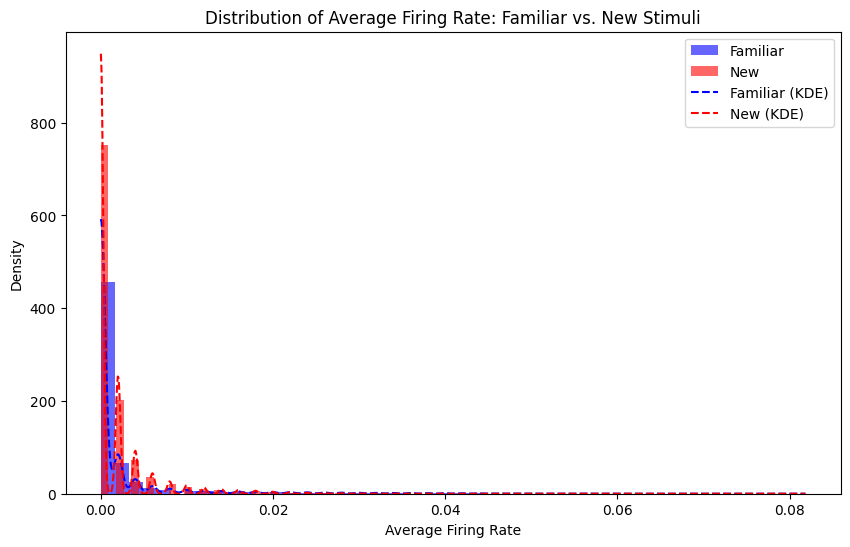

In [36]:
# Separate the data based on labels
familiar_data = avg_firing_rate[Y == 1]
new_data = avg_firing_rate[Y == 0]

# Plot the distributions for familiar and new classes
plt.figure(figsize=(10, 6))
plt.hist(familiar_data.flatten(), bins=50, alpha=0.6, label="Familiar", color='blue', density=True)
plt.hist(new_data.flatten(), bins=50, alpha=0.6, label="New", color='red', density=True)

# Use Kernel Density Estimation (KDE) for smooth curves
familiar_kde = gaussian_kde(familiar_data.flatten())
new_kde = gaussian_kde(new_data.flatten())
x = np.linspace(min(familiar_data.min(), new_data.min()), max(familiar_data.max(), new_data.max()), 1000)
plt.plot(x, familiar_kde(x), label="Familiar (KDE)", color='blue', linestyle='--')
plt.plot(x, new_kde(x), label="New (KDE)", color='red', linestyle='--')

plt.title('Distribution of Average Firing Rate: Familiar vs. New Stimuli')
plt.xlabel('Average Firing Rate')
plt.ylabel('Density')
plt.legend()
plt.show()

# Why KDE?
- KL Divergence is commonly used to compare two probability distributions. In this case, it allows us to quantify how similar or different the firing activity of the neurons is between the familiar and new classes.
- It's is a good choice for comparing distributions because it quantifies how different the distributions are and can give us insight into how separable the two classes are.


In [38]:
# First, we'll compute the probability densities for each class using KDE
familiar_density = familiar_kde(x)
new_density = new_kde(x)

# To avoid division by zero, add a small value to the density
epsilon = 1e-10
familiar_density += epsilon
new_density += epsilon

# KL Divergence: D_KL(P || Q) = Σ P(x) * log(P(x) / Q(x))
kl_divergence_familiar_to_new = np.sum(familiar_density * np.log(familiar_density / new_density))
kl_divergence_new_to_familiar = np.sum(new_density * np.log(new_density / familiar_density))

print(f'KL Divergence (Familiar -> New): {kl_divergence_familiar_to_new}')
print(f'KL Divergence (New -> Familiar): {kl_divergence_new_to_familiar}')

KL Divergence (Familiar -> New): 4336.135099158216
KL Divergence (New -> Familiar): 3297.839521682831


- KL Divergence (Familiar -> New): A value of 4336.14 suggests that the distributions are fairly distinct.
- KL Divergence (New -> Familiar): The divergence of 3297.84 also indicates a significant difference between the two classes, but it’s slightly lower than the first value. This would mean that familiar class might have a more wider distribution than the new class.


# Model Training

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

## Comparing
- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

In [43]:
# Import necessary libraries for models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(avg_firing_rate, Y, test_size=0.2, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine (SVM)": SVC(random_state=42)
}

# Step 1: Train and evaluate each model
results = {}

for model_name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate Accuracy and F1-Score
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store the results
    results[model_name] = {"Accuracy": accuracy, "F1-Score": f1}

# Step 2: Print out the comparison of models
for model_name, metrics in results.items():
    print(f'{model_name}:')
    print(f'Accuracy: {metrics["Accuracy"]}')
    print(f'F1-Score: {metrics["F1-Score"]}')


Logistic Regression:
Accuracy: 0.7625
F1-Score: 0.7532467532467533
Random Forest:
Accuracy: 0.85
F1-Score: 0.8285714285714286
Support Vector Machine (SVM):
Accuracy: 0.84375
F1-Score: 0.8


# Interpretation of Results


- Random Forest, with an accuracy of 85% and an F1-score of 0.8286, outperformed the other models. This suggests that Random Forest is the most effective classifier for this task, likely due to its ability to model non-linear relationships and interactions between neurons.
- Support Vector Machine (SVM) performed similarly to Random Forest, with an accuracy of 84.375% and an F1-score of 0.8000. While slightly lower than Random Forest, SVM still performed strongly. It is particularly effective when the decision boundary is not linear.
- Logistic Regression performed reasonably well with an accuracy of 76.25% and an F1-score of 0.7532. This model is simple and effective but may not capture the underlying complexity in the data as well as more sophisticated models.

# Converting to PDF

In [52]:
!apt-get install texlive texlive-xetex texlive-fonts-recommended

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive is already the newest version (2021.20220204-1).
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-fonts-recommended set to manually installed.
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [53]:
from google.colab import files
files.download('Project.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
!jupyter nbconvert --to pdf Project.ipynb

[NbConvertApp] Converting notebook Project.ipynb to pdf
[NbConvertApp] Support files will be in Project_files/
[NbConvertApp] Making directory ./Project_files
[NbConvertApp] Writing 45401 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 148950 bytes to Project.pdf
